                        TASK-1

Problem 1

In [42]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [43]:
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [44]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

GPU is not detected so i will still explain why CPU is slower than GPU as it has very fewer cores than GPU and as CPU is optimised for sequential processing but on the other hand GPU is optimised on parallel computation.               On GPU the different ways we use are-using larger batch size due to its capacity to process bigger data                                               -training more complex data                        -using more epochs in lesser duration.             We are setting random seeds to ensure rperoducibility as if we use without seeds every run will give different results so to get same output every time we use seeds.                  ALL seeds controls different randomness astf.random.set_seed(42) tenflow (trains model) and controls neural network operations ,np.random.seed(42) controls numpy array operations,rnamdom seeds(42) control python randomm functions.

Problem 2

In [45]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

In [46]:
print("MNIST Training Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR-10 Training Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)

MNIST Training Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Training Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)


In [47]:
print("\nMNIST Data Type:", x_train_mnist.dtype)
print("MNIST Pixel Range:", x_train_mnist.min(), "to", x_train_mnist.max())

print("\nCIFAR-10 Data Type:", x_train_cifar.dtype)
print("CIFAR-10 Pixel Range:", x_train_cifar.min(), "to", x_train_cifar.max())


MNIST Data Type: uint8
MNIST Pixel Range: 0 to 255

CIFAR-10 Data Type: uint8
CIFAR-10 Pixel Range: 0 to 255


In [48]:
unique, counts = np.unique(y_train_mnist, return_counts=True)

print("\nMNIST Class Distribution:")
for i in range(len(unique)):
    print("Digit", unique[i], ":", counts[i], "samples")


MNIST Class Distribution:
Digit 0 : 5923 samples
Digit 1 : 6742 samples
Digit 2 : 5958 samples
Digit 3 : 6131 samples
Digit 4 : 5842 samples
Digit 5 : 5421 samples
Digit 6 : 5918 samples
Digit 7 : 6265 samples
Digit 8 : 5851 samples
Digit 9 : 5949 samples


(a) Shape of dataset=
MNIST training shape= (60000, 28, 28)
MNIST test shape= (10000, 28, 28)
CIFAR-10 training shape= (50000, 32, 32, 3)
CIFAR-10 test shape= (10000, 32, 32, 3)            (b) Data types and pixel range=
Data types of image(MNIST and CIFAR-10)= uint8
Pixel values range from= 0 to 255 For both MNIST and CIFAR-10                                       (c) Class distributions in MNIST=
Each digit (0–9) has approximately 6000 samples
So,we can say that the dataset is balanced because all classes have almost similar number of samples.

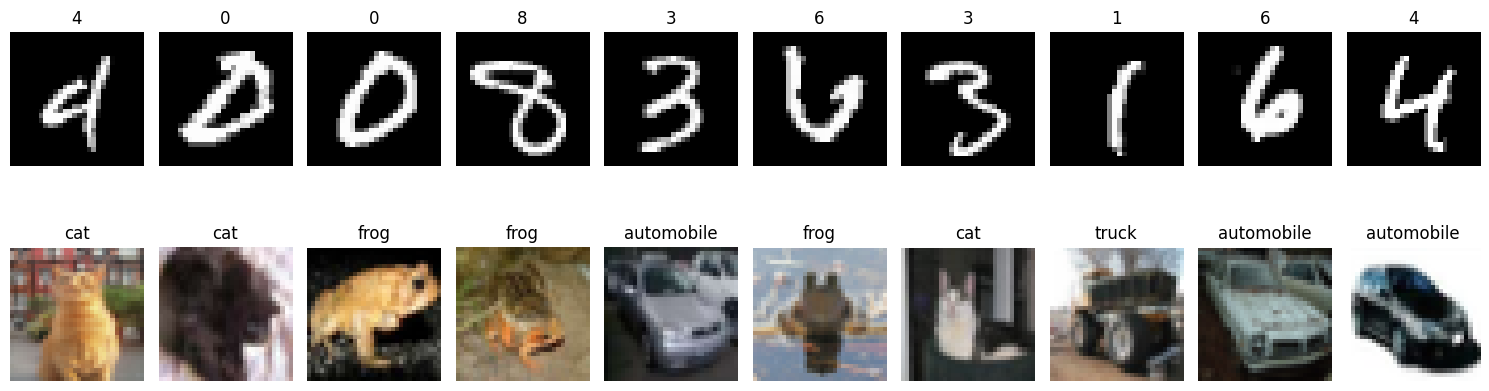

In [49]:
import matplotlib.pyplot as plt
import numpy as np


cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,5))

mnist_indices = np.random.choice(len(x_train_mnist), 10)

for i, idx in enumerate(mnist_indices):
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(y_train_mnist[idx])
    plt.axis('off')


cifar_indices = np.random.choice(len(x_train_cifar), 10)

for i, idx in enumerate(cifar_indices):
    plt.subplot(2, 10, i+11)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')


plt.tight_layout()

plt.show()

Problem 3

Normalisation

In [50]:
x_train_mnist = x_train_mnist.astype('float32') / 255.0

In [51]:
print("After normalization:")
print("Data type:", x_train_mnist.dtype)
print("Range:", x_train_mnist.min(), "to", x_train_mnist.max())

After normalization:
Data type: float32
Range: 0.0 to 1.0


Reshape

In [52]:
x_train_mnist = x_train_mnist.reshape(-1,28,28,1)

In [53]:
print("\nAfter reshaping:")
print("Shape:", x_train_mnist.shape)


After reshaping:
Shape: (60000, 28, 28, 1)


one-hot

In [54]:
y_onehot = np.zeros((len(y_train_mnist),10))
for i in range(len(y_train_mnist)):
    y_onehot[i, y_train_mnist[i]] = 1

In [55]:
print("\nAfter one-hot encoding:")
print("Shape:", y_onehot.shape)
print("Sample:\n", y_onehot[:5])


After one-hot encoding:
Shape: (60000, 10)
Sample:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Problem4

In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [57]:
indices = np.random.choice(len(x_train_cifar), 5)
sample_images = x_train_cifar[indices]

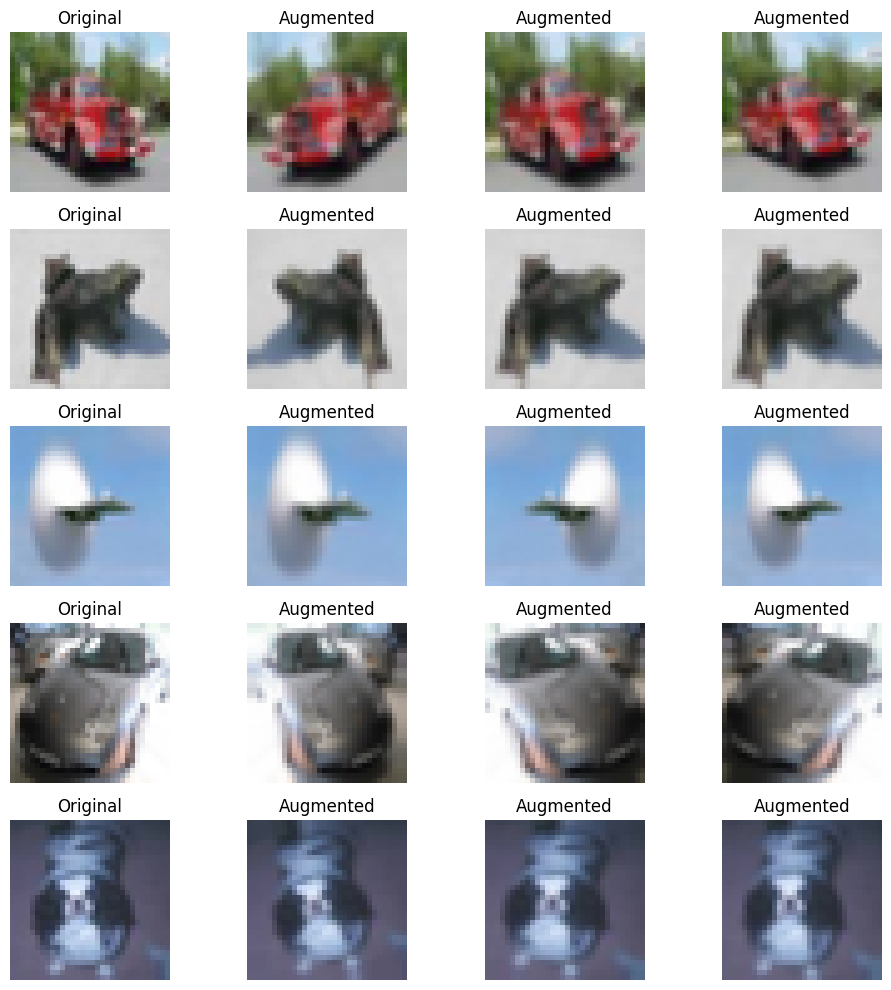

In [58]:
plt.figure(figsize=(10,10))

for i in range(5):

    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(sample_images[i])
    plt.title("Original")
    plt.axis('off')

    img = sample_images[i].reshape((1,32,32,3))

    aug_iter = datagen.flow(img, batch_size=1)

    for j in range(3):
        aug_img = next(aug_iter)[0].astype('uint8')

        plt.subplot(5, 4, i*4 + 2 + j)
        plt.imshow(aug_img)
        plt.title("Augmented")
        plt.axis('off')

plt.tight_layout()

plt.show()

Augmenation only works for training dataset because as it helps the model to learn better by increasing the diversity of data and reducing its overfitting.The test set must not change so it can represent real-world data and do the fair evaluation of model's performance.Due to applying augmentaion it can give misleading results and make performance evalution incorrect.

ANALYTICAL QUESTIONS

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters. Which uses fewer parameters? Show numerical proof and explain any other advantages of the smaller kernel approach.                                  ANS.One 5×5 Convo Layer

Parameter formula:
Params=(5X5XC+1)XF                               Two 3×3 Conv Layers
First layer:(3×3×C+1)×F=(9C+1)F
Second layer:

Input channels = F
(3×3×F+1)×F=(9F+1)F                               Total parameters:
(9C+1)F+(9F+1)F                                    Although two 3×3 layers have more parameters than one 5×5 layer but Two 3×3 layers give Same receptive field (5×5)But more non-linearity.      numeerical-Let,

C = 3 (RGB image)
F = 64 filters                                    for 5×5 layer,(25×3+1)×64=(75+1)×64=76×64=4864
for two 3x3 layer,(9×3+1)×64=(27+1)×64=28×64=1792  (9×3+1)×64=(27+1)×64=28×64=1792,1792+36928=38720

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.                                        ANS.Batch normalisation is used to normalize the output of a layer so that it has(mean ≈ 0,variance ≈ 1).This makes training more stable and faster.   Batch norm is placed before activation,placing it before activation function gives better and more stable results.it has higher learning rate and it act as regulisation.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?                                        ANS.GAP layer takes each feature map and computes the average of all the values of the map.Parameter Count with GAP is very few parameters as Output size is equal to C but for Flatten Output size is H × W × C which is much bigger input to Dense layer and creates large increase in parameters.


                                       TASK-2

Problem 1

In [59]:
def conv2d(image, kernel, stride=1, padding=0):

    H, W = image.shape
    kH, kW = kernel.shape

    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')


    H_p, W_p = image.shape

    out_H = (H_p - kH) // stride + 1
    out_W = (W_p - kW) // stride + 1


    output = np.zeros((out_H, out_W))


    for i in range(out_H):
        for j in range(out_W):


            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]


            output[i, j] = np.sum(patch * kernel)

    return output



In [60]:
image = np.array([
    [3,1,0,2,4],[1,5,3,2,1],[0,2,6,4,3],[2,3,1,5,2],[1,0,2,3,4]
])

In [61]:
kernel = np.array([
    [-1,0,1],[-2,0,2], [-1,0,1]
])

In [62]:
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Problem 2

Output=[(Input−Kernel+2×Padding)/stride​]+1       a)[(28−5+0)/1]​+1=23+1=24 ,ans is 24x24                                             b)[(28−3+2)/1]​+1=27+1=28  ,ans is 28x28                                             c)[(32−3+0)/2]​+1=29/2​+1=15.5 so value is 15x15                                             d)First Layer,

Input = 32
K = 3, P = 1, S = 1
[(32−3+2)/1]=31+1=32                             Second Layer,

Input = 32
K = 3, P = 0, S = 1
[(32−3+0)/1]=29+1=30
	​
ans is 30x30


Problem 3

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten

model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', padding='valid', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

model.add(Conv2D(16, (5,5), activation='tanh', padding='valid'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

(b) Manual Parameter Calculation (First Conv Layer)=                              Params=(K×K×C+1)×C
out
	​


For first layer:

K = 5
C_in = 1 (grayscale MNIST)
C_out = 6

=(5×5×1+1)×6

=(25+1)×6=26×6=156                                                           (c) Why AvgPooling in LeNet-5 vs MaxPooling today?                           ANS.In LeNet-5, Average Pooling was used because early CNNs focused on smoothing features and reducing sensitivity to noise by averaging values in a region. But modern CNNs prefer MaxPooling because it selects the strongest activation, which helps preserve important features like edges and textures. MaxPooling also works better with ReLU activations and improves performance in deep networks.                                                               

Problem 4

a)Input (32×32×3)

↓ Conv Block 1
Conv2D(32) → BatchNorm → ReLU → MaxPool

↓ Conv Block 2
Conv2D(64) → BatchNorm → ReLU → MaxPool

↓ Conv Block 3
Conv2D(128) → BatchNorm → ReLU → MaxPool

↓ GlobalAveragePooling

↓ Dense(128) → ReLU

↓ Dropout(0.5)

↓ Dense(10) → Softmax (Output)                                                  b)This model uses three convolutional blocks to progressively extract features from low-level edges to high-level patterns. Batch Normalisation is applied after each convolution to stabilize training and improve convergence. MaxPooling is used to reduce spatial dimensions and control overfitting. GlobalAveragePooling9GAP) reduces the number of parameters before the Dense layers, and Dropout is added to prevent overfitting. The architecture balances complexity and efficiency to perform well on CIFAR-1.                     

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()


model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))


model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Now the expected parameter count is ~300K – 600K which is in the expected range of (200K–2M).

ANALYTICAL QUESTIONS

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach?                 ANS.On comparing One 5×5 Conv layer and two stacked 3×3 Conv layers Input ,we will assume channels = C and Number of filters = F                           for One 5×5 Convolution Layer Params=(5×5×C+1)×F=(25C+1)F                    for two 3×3 Convolution Layers
First layer:
(3×3×C+1)×F=(9C+1)F
Second layer:
(3×3×F+1)×F=(9F+1)F
Total:(9C+1)F+(9F+1)F                                                         ex.C=3,F=64                                                                    for 5×5 Conv:(25×3+1)×64=(75+1)×64=76×64=4864                                   for two 3×3 Conv:
First layer:(9×3+1)×64=28×64=1792
Second layer:(9×64+1)×64=577×64=36928
Total:1792+36928=38720                                                          Although two stacked 3×3 convolution layers may use more parameters when the number of filters is the same, they are preferred because they provide the same receptive field as a 5×5 layer while introducing additional non-linearity and improving feature learning.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training?                                                                ANS.Batch Normalisation is used to normalize the output of a layer so that the
mean ≈ 0 and Variance ≈ 1.This helps make training faster and more stable.it is placd before activation function to improve learning and stability.             Its two empirical benefits are 1) Faster Convergence in which model trains faster and requires fewer epochs.                                               2)it allows higher Learning Rate.     

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information  if you replaced it with
Flatten?                                                                     ANS.GlobalAveragePooling (GAP) layer takes each feature map and computes the average of all the values in it.If it is replaced with flatten then there will be huge increase in parameters and GAP loses spatial information (position of features)and keeps overall presence of features while Flatten preserves spatial arrangement keeps detailed structure of features.

                                                    TASK-3

Problem 1

In [72]:
(x_train_mnist, y_train_mnist), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1) / 255.0

y_onehot = tf.keras.utils.to_categorical(y_train_mnist, 10)


model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train_mnist, y_onehot,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9513 - loss: 0.1636 - val_accuracy: 0.9838 - val_loss: 0.0561
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9846 - loss: 0.0505 - val_accuracy: 0.9875 - val_loss: 0.0472
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9892 - loss: 0.0335 - val_accuracy: 0.9870 - val_loss: 0.0507
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9925 - loss: 0.0236 - val_accuracy: 0.9877 - val_loss: 0.0491
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9944 - loss: 0.0179 - val_accuracy: 0.9883 - val_loss: 0.0493
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9957 - loss: 0.0139 - val_accuracy: 0.9890 - val_loss: 0.0418
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9965 - loss: 0.0111 - val_accuracy: 0.9908 - val_loss: 0.0400
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.

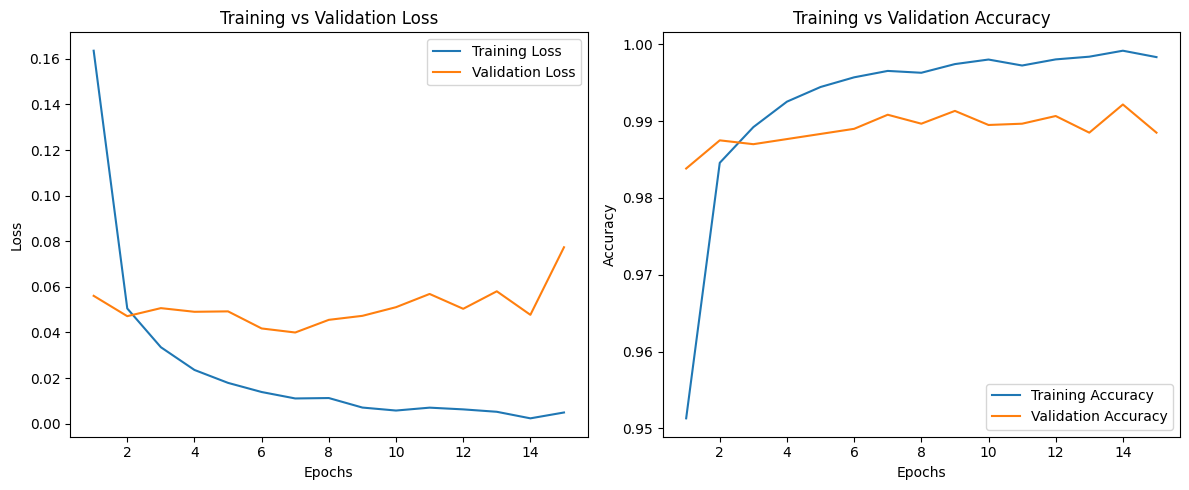

In [73]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()


plt.tight_layout()
plt.savefig('lenet_sgd_curves.png')

plt.show()

In [74]:
overfit_epoch = None

for i in range(1, len(val_loss)):
    if val_loss[i] > val_loss[i-1]:
        overfit_epoch = i + 1
        break

if overfit_epoch:
    print(f"Overfitting starts at epoch: {overfit_epoch}")
else:
    print("No clear overfitting observed")

Overfitting starts at epoch: 3


In [75]:

x_test = x_test.reshape(-1, 28, 28, 1) / 255.0
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)


test_loss, test_acc = model.evaluate(x_test, y_test_onehot)

print(f"Final Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9919 - loss: 0.0452
Final Test Accuracy: 0.9919


Problem 2

In [76]:
def create_lenet():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D(),

        tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [77]:
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

In [79]:
def create_lenet():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

        tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [80]:
histories = {}


model_sgd = create_lenet()
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

histories['SGD'] = model_sgd.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


model_momentum = create_lenet()
model_momentum.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

histories['SGD + Momentum'] = model_momentum.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


model_adam = create_lenet()
model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

histories['Adam'] = model_adam.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7586 - loss: 0.9288 - val_accuracy: 0.8997 - val_loss: 0.3968
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8891 - loss: 0.3995 - val_accuracy: 0.9228 - val_loss: 0.2837
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9091 - loss: 0.3167 - val_accuracy: 0.9372 - val_loss: 0.2321
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9222 - loss: 0.2666 - val_accuracy: 0.9465 - val_loss: 0.1964
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9333 - loss: 0.2289 - val_accuracy: 0.9548 - val_loss: 0.1690
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9416 - loss: 0.1990 - val_accuracy: 0.9603 - val_loss: 0.1475
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9492 - loss: 0.1750 - val_accuracy: 0.9647 - val_loss: 0.1305
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9549 - loss: 0.1556 - val_accuracy: 0.

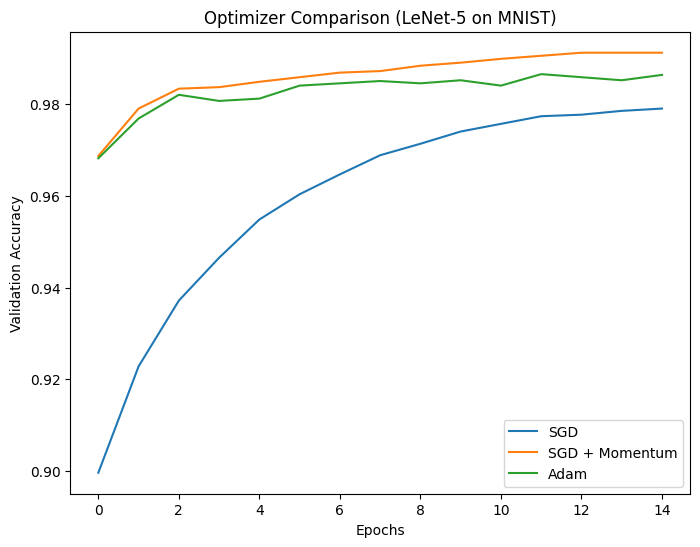

In [82]:
plt.figure(figsize=(8,6))

for name, history in histories.items():
    val_acc = history.history['val_accuracy']
    plt.plot(val_acc, label=name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Comparison (LeNet-5 on MNIST)')
plt.legend()

plt.show()

Problem 3

In [83]:
def create_cifar_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [84]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
import numpy as np

(x_train, y_train), _ = cifar10.load_data()

x_train = x_train / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

In [85]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nTraining with LR={lr}, Batch Size={bs}")

        model = create_cifar_model()

        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train, y_train,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=1
        )

        final_val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = final_val_acc


Training with LR=0.1, Batch Size=32
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3956 - loss: 1.6853 - val_accuracy: 0.4916 - val_loss: 1.4548
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5535 - loss: 1.2573 - val_accuracy: 0.5282 - val_loss: 1.4445
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6245 - loss: 1.0619 - val_accuracy: 0.5994 - val_loss: 1.1992
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6773 - loss: 0.9143 - val_accuracy: 0.6166 - val_loss: 1.1242
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7278 - loss: 0.7811 - val_accuracy: 0.6162 - val_loss: 1.1824
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7704 - loss: 0.6573 - val_accuracy: 0.6304 - val_loss: 1.2095
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8075 - loss: 0.5504 - val_accuracy: 0.6298 - val_loss: 1.4454
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

In [86]:
print("\nFinal Validation Accuracy Table:\n")

print("LR \\ Batch\t32\t\t128")

best_acc = 0
best_combo = None

for lr in learning_rates:
    row = f"{lr}\t\t"
    for bs in batch_sizes:
        acc = results[(lr, bs)]
        row += f"{acc:.4f}\t"

        if acc > best_acc:
            best_acc = acc
            best_combo = (lr, bs)
    print(row)

print(f"\nBest Combination: LR={best_combo[0]}, Batch Size={best_combo[1]}")
print(f"Best Validation Accuracy: {best_acc:.4f}")


Final Validation Accuracy Table:

LR \ Batch	32		128
0.1		0.5852	0.6574	
0.01		0.6310	0.5072	
0.001		0.3964	0.2812	

Best Combination: LR=0.1, Batch Size=128
Best Validation Accuracy: 0.6574


Problem 4

In [87]:
def create_model(use_dropout=False, use_bn=False):
    model = tf.keras.models.Sequential()


    model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))


    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.5))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

In [88]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), _ = cifar10.load_data()

x_train = x_train / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)

In [89]:
configs = {
    "No Reg": (False, False),
    "Dropout Only": (True, False),
    "BatchNorm Only": (False, True),
    "Dropout + BatchNorm": (True, True)
}

histories = {}
gaps = {}

for name, (use_dropout, use_bn) in configs.items():
    print(f"\nTraining: {name}")

    model = create_model(use_dropout, use_bn)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    histories[name] = history


    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gaps[name] = train_acc - val_acc


Training: No Reg
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4473 - loss: 1.5339 - val_accuracy: 0.5336 - val_loss: 1.2856
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5746 - loss: 1.2029 - val_accuracy: 0.6062 - val_loss: 1.1196
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6286 - loss: 1.0618 - val_accuracy: 0.6390 - val_loss: 1.0383
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6640 - loss: 0.9674 - val_accuracy: 0.6686 - val_loss: 0.9754
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6924 - loss: 0.8916 - val_accuracy: 0.6786 - val_loss: 0.9374
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7168 - loss: 0.8265 - val_accuracy: 0.6864 - val_loss: 0.9230
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7343 - loss: 0.7709 - val_accuracy: 0.6926 - val_loss: 0.9137
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7526 - loss: 0.7173 

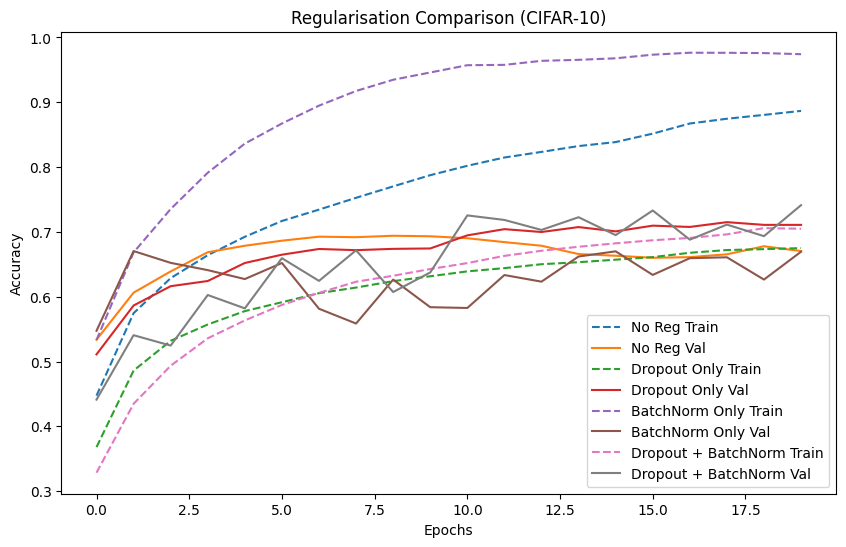

In [90]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['accuracy'], linestyle='--', label=f"{name} Train")
    plt.plot(history.history['val_accuracy'], label=f"{name} Val")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Regularisation Comparison (CIFAR-10)")
plt.legend()

plt.show()

In [91]:
print("\nTrain - Validation Accuracy Gap (Final Epoch):\n")
print("Model\t\t\tGap")

for name, gap in gaps.items():
    print(f"{name:25s} {gap:.4f}")


Train - Validation Accuracy Gap (Final Epoch):

Model			Gap
No Reg                    0.2162
Dropout Only              -0.0359
BatchNorm Only            0.3047
Dropout + BatchNorm       -0.0364


Problem 5

In [110]:
class LrLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.lrs.append(lr)

In [112]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-5
)

In [113]:
lr_logger = LrLogger()

model_plateau = get_compiled_model(0.001)

history_plateau = model_plateau.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, lr_logger],
    verbose=1
)

lr_plateau = lr_logger.lrs

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.3222 - loss: 1.8759 - val_accuracy: 0.4440 - val_loss: 1.5313 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4389 - loss: 1.5487 - val_accuracy: 0.4824 - val_loss: 1.5027 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4949 - loss: 1.4095 - val_accuracy: 0.5332 - val_loss: 1.4086 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5318 - loss: 1.3163 - val_accuracy: 0.5978 - val_loss: 1.1556 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5652 - loss: 1.2349 - val_accuracy: 0.5294 - val_loss: 1.5290 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5840 - loss: 1.1819 - val_accuracy: 0.6294 - val_loss: 1.0982 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6054 - loss: 1.1266 

In [114]:
class CosineAnnealingScheduler(tf.keras.callbacks.Callback):
    def __init__(self, initial_lr, epochs):
        self.initial_lr = initial_lr
        self.epochs = epochs
        self.lrs = []

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.initial_lr * (1 + np.cos(np.pi * epoch / self.epochs)) / 2
        self.model.optimizer.learning_rate.assign(lr)
        self.lrs.append(lr)

In [115]:
cosine_cb = CosineAnnealingScheduler(0.001, 30)

model_cosine = get_compiled_model(0.001)

history_cosine = model_cosine.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[cosine_cb],
    verbose=1
)

lr_cosine = cosine_cb.lrs

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.3360 - loss: 1.8368 - val_accuracy: 0.4556 - val_loss: 1.6508
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4538 - loss: 1.5116 - val_accuracy: 0.4876 - val_loss: 1.4493
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5143 - loss: 1.3670 - val_accuracy: 0.4966 - val_loss: 1.3901
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5538 - loss: 1.2621 - val_accuracy: 0.6290 - val_loss: 1.0275
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5778 - loss: 1.1948 - val_accuracy: 0.6520 - val_loss: 0.9808
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6042 - loss: 1.1271 - val_accuracy: 0.6496 - val_loss: 0.9961
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6217 - loss: 1.0793 - val_accuracy: 0.6334 - val_loss: 1.0282
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6376 - loss: 1.0405 - val_accuracy: 

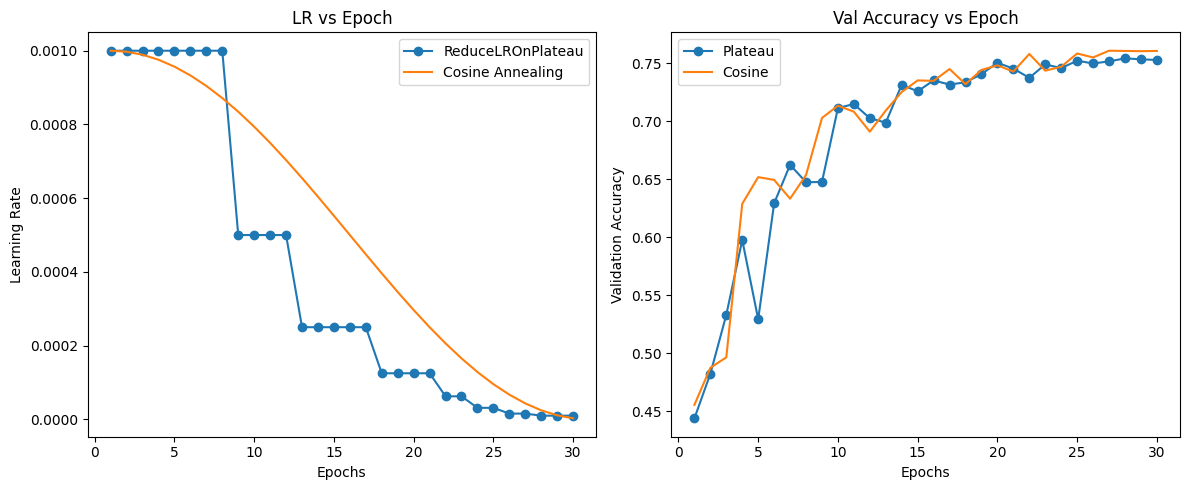

In [116]:
import matplotlib.pyplot as plt

epochs = range(1, 31)

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(epochs, lr_plateau, 'o-', label='ReduceLROnPlateau')   # step-like
plt.plot(epochs, lr_cosine, '-', label='Cosine Annealing')      # smooth
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('LR vs Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_plateau.history['val_accuracy'], 'o-', label='Plateau')
plt.plot(epochs, history_cosine.history['val_accuracy'], '-', label='Cosine')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Val Accuracy vs Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png')
plt.show()

ANALYTICAL QUESTIONS

Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than
converge. Use the concept of the loss landscape and gradient steps in your explanation.                                                                    ANS.The update rule is:
θ=θ−η⋅∇L(θ)where
θ = parameters,η = learning rate,∇L(θ) = gradient (direction of steepest increase)
Learning rate controls step size                                                A very high learning rate causes training loss to diverge or oscillate because it leads to excessively large parameter updates in gradient descent. Instead of gradually descending the loss landscape toward a minimum, the updates overshoot the optimal point and jump across the valley repeatedly, causing oscillations. In regions with steep gradients, the large step size can push the parameters further away from the minimum, leading to increasing loss values and divergence. Therefore, an appropriate learning rate is necessary to ensure stable and gradual convergence.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best
accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis explaining the pattern you observed                                                                      ANS.The best performing combination was a low learning rate (0.001) with a smaller batch size (32), while the worst performance was observed with a high learning rate (0.1) and a larger batch size (128). This pattern can be explained by the fact that smaller learning rates allow stable convergence without overshooting the minimum, whereas large learning rates cause unstable updates and poor convergence. Additionally, smaller batch sizes introduce noise in gradient updates, which helps the model generalize better, while larger batch sizes produce smoother gradients but may lead to poorer generalization. Therefore, a combination of low learning rate and small batch size results in the best performance.

Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction
must be applied to the surviving activations during inference to maintain the expected output magnitude?                                                      ANS.Dropout is disabled during inference because we want to use the full network without randomness to obtain stable and deterministic predictions. During training, dropout randomly deactivates neurons, reducing the effective output. To maintain the expected output magnitude, scaling is required. For a dropout rate of 0.5, the surviving activations must be scaled by the keep probability (0.5) during inference. However, in modern implementations using inverted dropout, scaling is applied during training itself (by multiplying activations by 1/0.5 = 2), so no scaling is required during inference.

Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii)
the shape of the LR curve, and (iii) which scenario each is better suited for.  ANS.ReduceLROnPlateau reduces the learning rate based on validation performance, specifically when the validation loss stops improving for a specified number of epochs, making it adaptive. In contrast, Cosine Annealing follows a predefined schedule and reduces the learning rate based on the epoch number without considering model performance. The learning rate curve of ReduceLROnPlateau is step-like, with sudden drops, whereas Cosine Annealing produces a smooth, continuous cosine-shaped decay. ReduceLROnPlateau is better suited for scenarios where training behavior is unpredictable and requires adaptive control, while Cosine Annealing is preferred when the number of training epochs is fixed and smooth convergence is desired.

                                                            TASK-4

Problem 1

In [118]:
conv1 = model.layers[0]

filters = conv1.get_weights()[0]

print("Filter shape:", filters.shape)

Filter shape: (3, 3, 3, 32)


In [119]:
f_min = filters.min(axis=(0,1,2), keepdims=True)
f_max = filters.max(axis=(0,1,2), keepdims=True)

filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

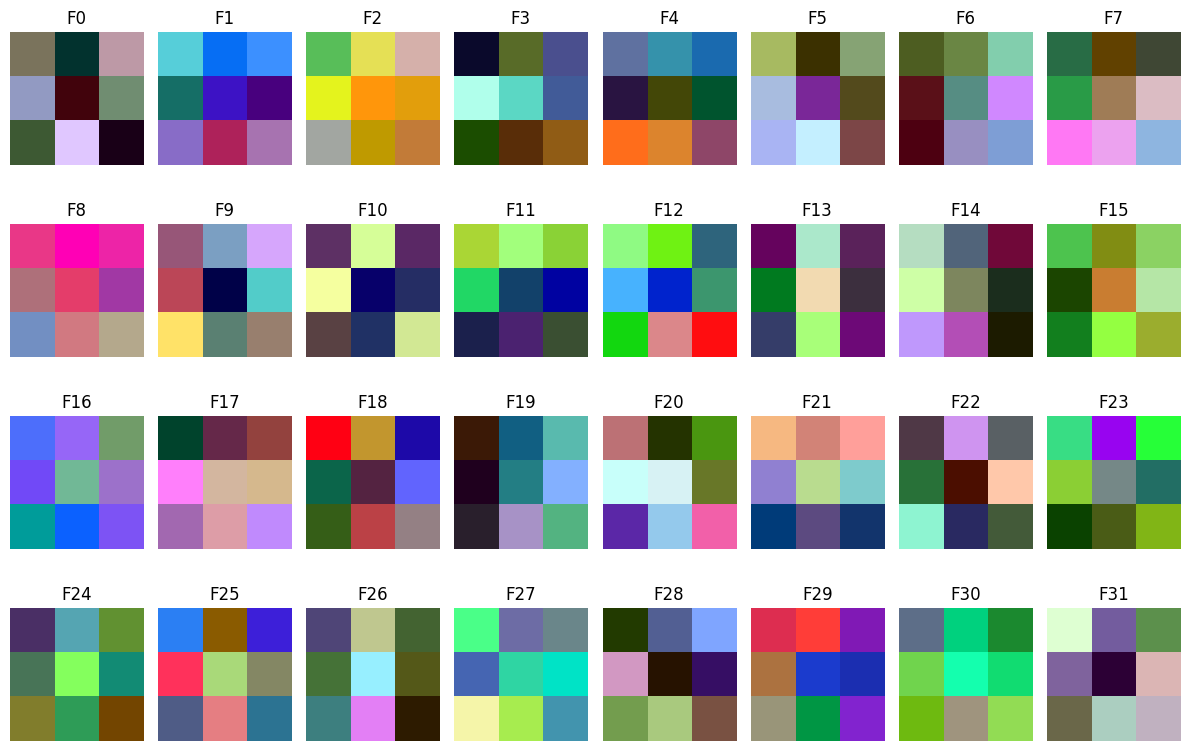

In [120]:
num_filters = filters.shape[-1]


cols = 8
rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(12, rows*2))

for i in range(num_filters):
    f = filters_norm[:,:,:,i]

    plt.subplot(rows, cols, i+1)
    plt.imshow(f)
    plt.title(f"F{i}")
    plt.axis('off')

plt.tight_layout()


plt.savefig('conv1_filters.png')

plt.show()

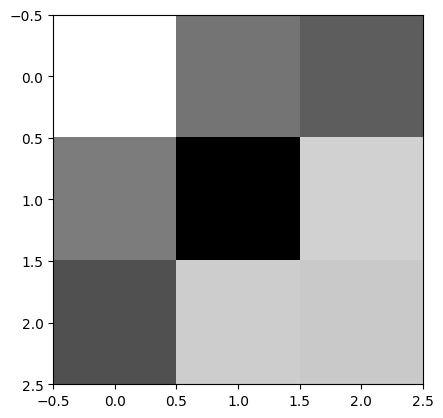

In [121]:
f = np.mean(filters_norm[:,:,:,i], axis=2)
plt.imshow(f, cmap='gray')

The filters learned in the first convolutional layer show basic visual patterns such as edges and color contrasts. Some filters appear to detect horizontal edges, where there is a clear transition from dark to light regions across rows. Others resemble vertical edge detectors, highlighting intensity changes across columns. A few filters capture diagonal textures, showing patterns that respond to slanted lines. Additionally, some filters emphasize color contrasts, such as differences between red and green channels.

These learned filters resemble classical edge detectors such as Sobel kernels and Gabor filters encountered earlier. Like Sobel filters, they detect gradients in specific directions (horizontal or vertical). Similar to Gabor filters, some exhibit orientation sensitivity and texture-like patterns. This shows that the CNN automatically learns low-level visual features similar to hand-crafted filters.

Problem 2

In [122]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test / 255.0

preds = model.predict(x_test)


for i in range(len(x_test)):
    if np.argmax(preds[i]) == y_test[i]:
        img = x_test[i]
        label = y_test[i]
        break

img_input = np.expand_dims(img, axis=0)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [129]:
def create_model(use_dropout=False, use_bn=False):
    inputs = tf.keras.Input(shape=(32,32,3))

    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
    if use_bn:
        x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    if use_dropout:
        x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
    if use_bn:
        x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    if use_dropout:
        x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    if use_dropout:
        x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)